In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("plots.mplstyle")

MU0 = 4 * np.pi * 1e-7  # T*m/A

# Coil on-axis magnetic field

A coil of diameter `d`, axial thickness `t`, `n` turns (spread uniformly over the thickness), and current `i` is modeled as a stack of circular loops of radius `d/2` filling the length `t`. Integrating the single-loop on-axis field over that stack gives the on-axis field a distance `z` from the coil's center:

$$B_z(z) = \frac{\mu_0 n i}{2t}\left[\frac{z + t/2}{\sqrt{(d/2)^2 + (z+t/2)^2}} - \frac{z - t/2}{\sqrt{(d/2)^2 + (z-t/2)^2}}\right]$$

which reduces to the familiar single-loop formula $B_z(z) = \mu_0 n i (d/2)^2 / [2((d/2)^2+z^2)^{3/2}]$ as `t -> 0`.

In [2]:
def coil_bz(z, d, t, n, i):
    """On-axis field [T] of a coil (diameter d, axial thickness t, n turns,
    current i) at distance z from its center, all in SI units (m, A)."""
    r = d / 2
    prefactor = MU0 * n * i / (2 * t)
    term_plus = (z + t / 2) / np.sqrt(r**2 + (z + t / 2) ** 2)
    term_minus = (z - t / 2) / np.sqrt(r**2 + (z - t / 2) ** 2)
    return prefactor * (term_plus - term_minus)

In [3]:
T_MM = 15.552 - 2 * 2.592  # coil axial thickness, mm
D_MM = 2 * 31.4  # coil diameter, mm
N_TURNS = 68
I_A = 2.0  # current, A

z_mm = np.linspace(-100, 100, 1000)
bz_mt = coil_bz(z_mm * 1e-3, D_MM * 1e-3, T_MM * 1e-3, N_TURNS, I_A) * 1e3

## NV frequency splitting vs. Bz

This diamond is (100)-cut and the coil's z-axis is aligned with the [100] cut-face normal, same as the field direction above. The four NV symmetry axes run along the <111> directions, not [100], so the field sits at the crystallographic "magic angle" (~54.74 deg) to every NV axis -- identical for all four orientations by symmetry, giving 2 resolvable ODMR peaks whose splitting requires diagonalizing the spin-1 Hamiltonian (not the simple on-axis `D +- gamma*B`). Model ported from `experiment/nv_center.ipynb`.

In [4]:
D_MHZ = 2870.0  # zero-field splitting
GAMMA_E_MHZ_PER_MT = 28.02495  # electron gyromagnetic ratio
MAGIC_ANGLE_DEG = np.degrees(np.arccos(1 / np.sqrt(3)))


def build_hamiltonian_mhz(b_mt, angle_deg, d_mhz, e_mhz, gamma_mhz_per_mt):
    theta = np.radians(angle_deg)
    gamma_b_mhz = gamma_mhz_per_mt * b_mt
    bz = gamma_b_mhz * np.cos(theta)
    bx = gamma_b_mhz * np.sin(theta)
    return np.array([
        [d_mhz + bz,      bx / np.sqrt(2), e_mhz],
        [bx / np.sqrt(2), 0.0,             bx / np.sqrt(2)],
        [e_mhz,           bx / np.sqrt(2), d_mhz - bz],
    ])


def nv_resonance_frequencies(b_mt, angle_deg=MAGIC_ANGLE_DEG, d_mhz=D_MHZ,
                              e_mhz=0.0, gamma_mhz_per_mt=GAMMA_E_MHZ_PER_MT):
    """Two ODMR resonance frequencies [MHz] for an NV center in a static
    field of b_mt mT, applied at angle_deg to the NV axis (default: the
    magic angle, i.e. field along [100] on this (100)-cut diamond)."""
    H = build_hamiltonian_mhz(b_mt, angle_deg, d_mhz, e_mhz, gamma_mhz_per_mt)
    energies, vectors = np.linalg.eigh(H)
    ms0_idx = np.argmax(np.abs(vectors[1, :]) ** 2)
    ref_energy = energies[ms0_idx]
    others = [energies[i] for i in range(3) if i != ms0_idx]
    f_low, f_high = sorted(abs(e - ref_energy) for e in others)
    return f_low, f_high


def nv_splitting_mhz(b_mt_array):
    return np.array([np.diff(nv_resonance_frequencies(b))[0] for b in b_mt_array])

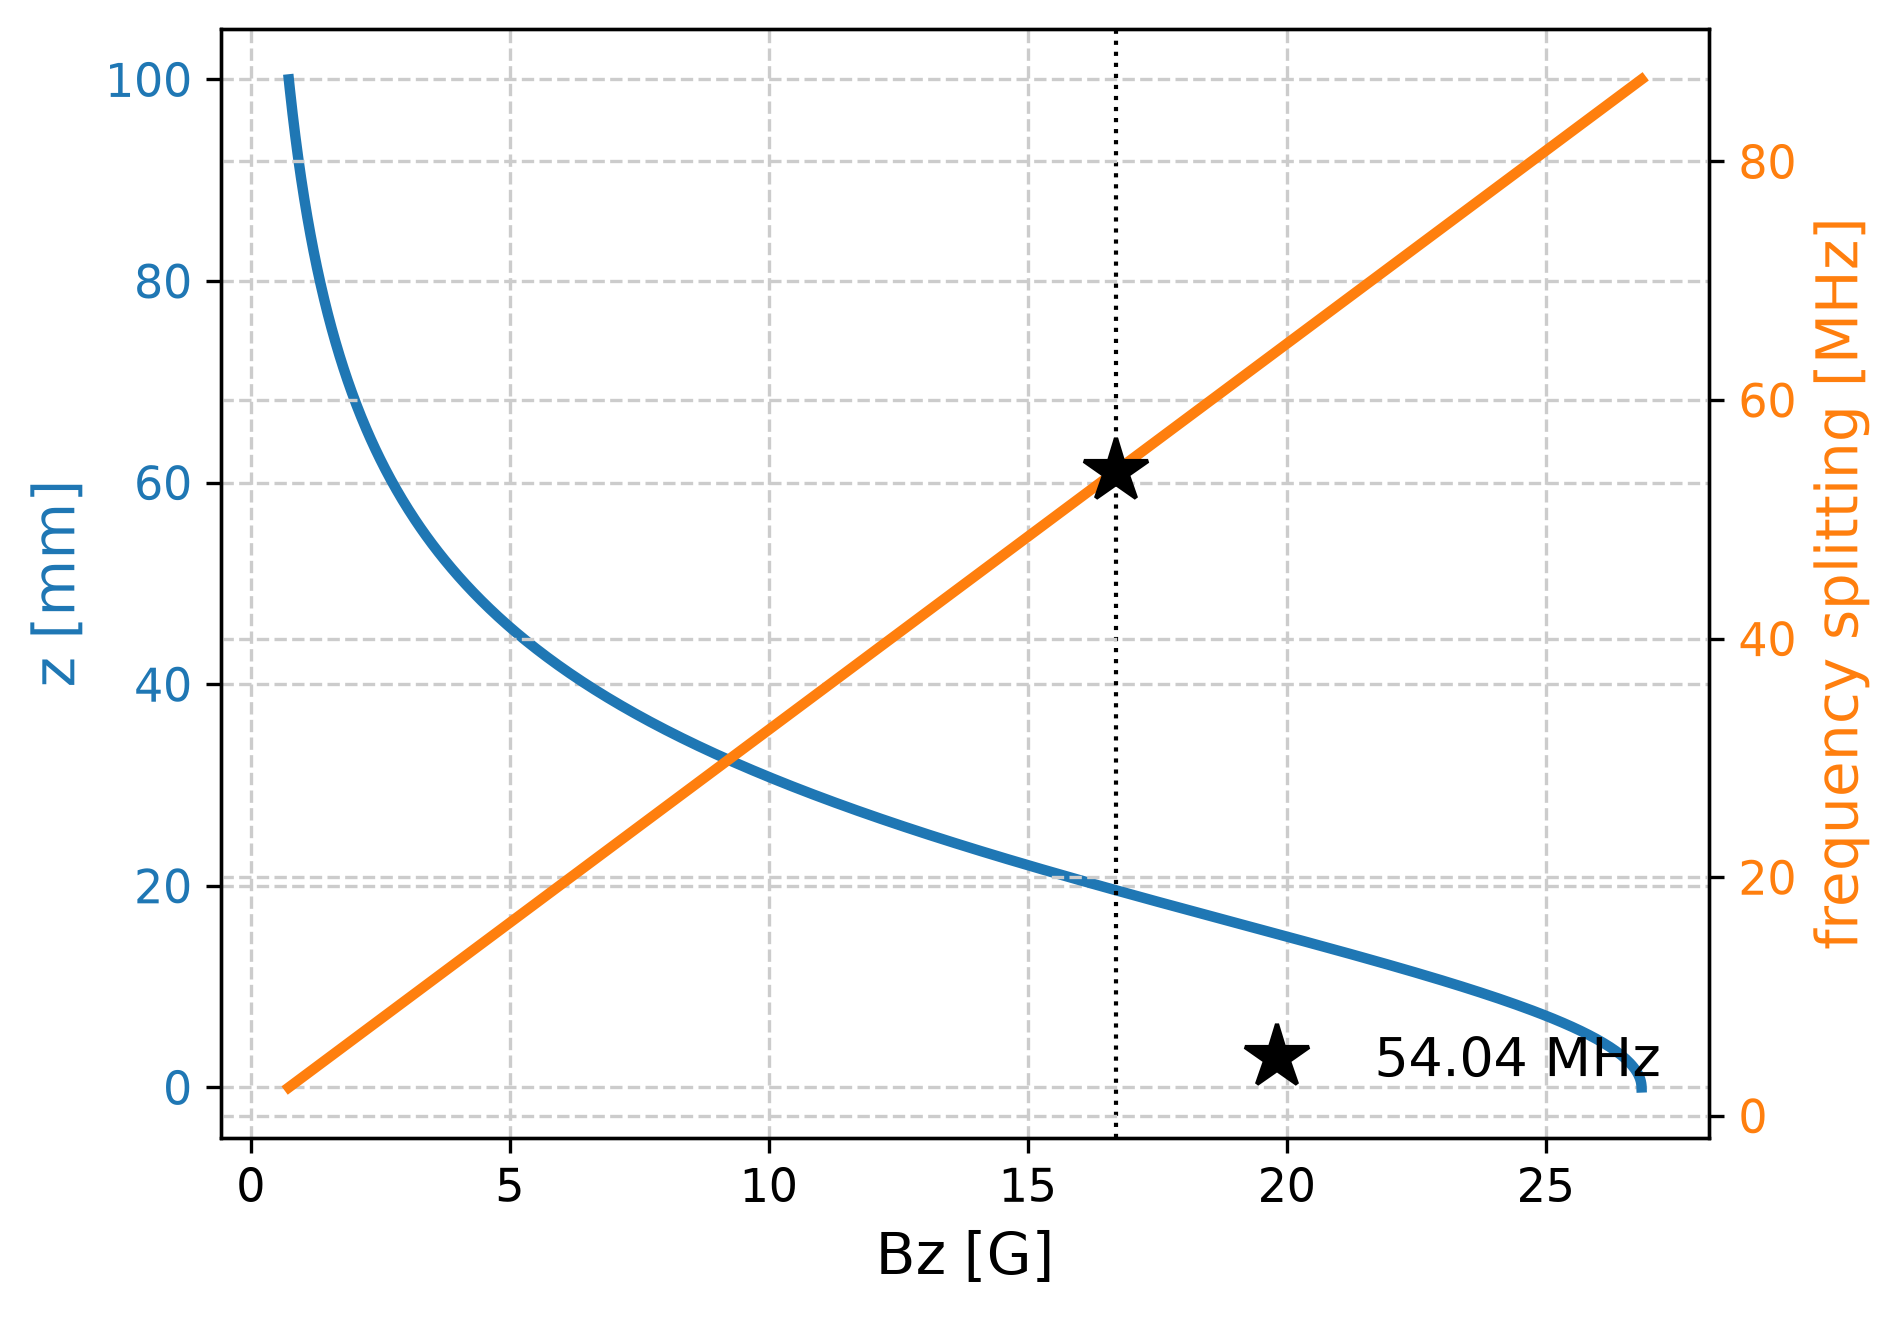

54.04 MHz splitting -> Bz = 16.70 G -> z = 19.56 mm


In [5]:
TARGET_SPLITTING_MHZ = 54.04

# Use the z >= 0 half, where Bz(z) is monotonic, so Bz can be used as the x-axis.
z_half_mm = np.linspace(0, 100, 500)
bz_half_mt = coil_bz(z_half_mm * 1e-3, D_MM * 1e-3, T_MM * 1e-3, N_TURNS, I_A) * 1e3
bz_half_g = bz_half_mt * 10  # 1 mT = 10 G
splitting_half_mhz = nv_splitting_mhz(bz_half_mt)

# Invert splitting(Bz) to find the field where splitting = TARGET_SPLITTING_MHZ,
# and z(Bz) to find the corresponding position.
order = np.argsort(splitting_half_mhz)
bz_star_g = np.interp(TARGET_SPLITTING_MHZ, splitting_half_mhz[order], bz_half_g[order])
z_star_mm = np.interp(bz_star_g, bz_half_g[::-1], z_half_mm[::-1])

fig, ax1 = plt.subplots(dpi=300)

ax1.plot(bz_half_g, z_half_mm, color="C0")
ax1.set_xlabel("Bz [G]")
ax1.set_ylabel("z [mm]", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.axvline(bz_star_g, color="black", linestyle=":", linewidth=1)

ax2 = ax1.twinx()
ax2.plot(bz_half_g, splitting_half_mhz, color="C1")
ax2.plot(
    bz_star_g,
    TARGET_SPLITTING_MHZ,
    marker="*",
    markersize=16,
    color="black",
    linestyle="none",
    zorder=5,
    label=f"{TARGET_SPLITTING_MHZ:.2f} MHz",
)
ax2.set_ylabel("frequency splitting [MHz]", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
ax2.legend(loc="lower right")

plt.show()

print(f"{TARGET_SPLITTING_MHZ:.2f} MHz splitting -> Bz = {bz_star_g:.2f} G -> z = {z_star_mm:.2f} mm")